In [44]:
import pandas as pd
import monai as mn
import SimpleITK as sitk
import matplotlib.pyplot as plt

In [2]:
df_train = pd.read_csv('Emory_CXR_Frontal_train.csv').drop(columns=['Unnamed: 0'])
df_test = pd.read_csv('Emory_CXR_Frontal_test.csv').drop(columns=['Unnamed: 0'])

In [ ]:
df_test = df_test[['PID','Path_LUT','Path_noLUT','Edema','Consolidation','Pneumonia','Pneumothorax','Pleural Effusion']]
df_test

In [105]:
trans_eq = mn.transforms.Compose([
    mn.transforms.HistogramNormalize(num_bins=256, min=0, max=255),
    mn.transforms.Resize(size_mode="longest", mode="bilinear", spatial_size=256, align_corners=False),
    mn.transforms.ScaleIntensityRangePercentiles(lower=0, upper=100, b_min=-1, b_max=1, clip=True),
    mn.transforms.SpatialPad(spatial_size=(256, 256), mode="constant", constant_values=0)])

trans_noeq = mn.transforms.Compose([
    mn.transforms.Resize(size_mode="longest", mode="bilinear", spatial_size=256, align_corners=False),
    mn.transforms.ScaleIntensityRangePercentiles(lower=0, upper=100, b_min=-1, b_max=1, clip=True),
    mn.transforms.SpatialPad(spatial_size=(256, 256), mode="constant", constant_values=0)])

In [106]:
def plot_CXR(df_test, pathology):
    df_plot = df_test[df_test[pathology] == 1].sample(n=1)
    plt.figure(figsize=(15, 15))
    
    # Reduce the space between the title and subplots
    plt.suptitle(f'{pathology}', y=0.92)
    
    # Reduce the space between subplots
    plt.subplots_adjust(wspace=0.1, hspace=0.1)
    
    im = sitk.ReadImage(df_plot['Path_LUT'])
    im_arr = sitk.GetArrayFromImage(im)
    im_eq = trans_eq(im_arr)
    im_noeq = trans_noeq(im_arr)
    
    im_noLUT = sitk.ReadImage(df_plot['Path_noLUT'])
    im_arr_noLUT = sitk.GetArrayFromImage(im_noLUT)
    im_eq_noLUT = trans_eq(im_arr_noLUT)
    im_noeq_noLUT = trans_noeq(im_arr_noLUT)
    
    plt.subplot(2, 2, 1)
    plt.imshow(im_eq[0], cmap='gray')
    plt.title('Equalized')
    plt.axis('off')
    
    plt.subplot(2, 2, 2)
    plt.imshow(im_noeq[0], cmap='gray')
    plt.title("Not Equalized")
    plt.axis('off')
    
    plt.subplot(2, 2, 3)
    plt.imshow(im_eq_noLUT[0], cmap='gray')
    plt.title('Equalized (no LUT)')
    plt.axis('off')
    
    plt.subplot(2, 2, 4)
    plt.imshow(im_noeq_noLUT[0], cmap='gray')
    plt.title("Not Equalized (no LUT)")
    plt.axis('off')


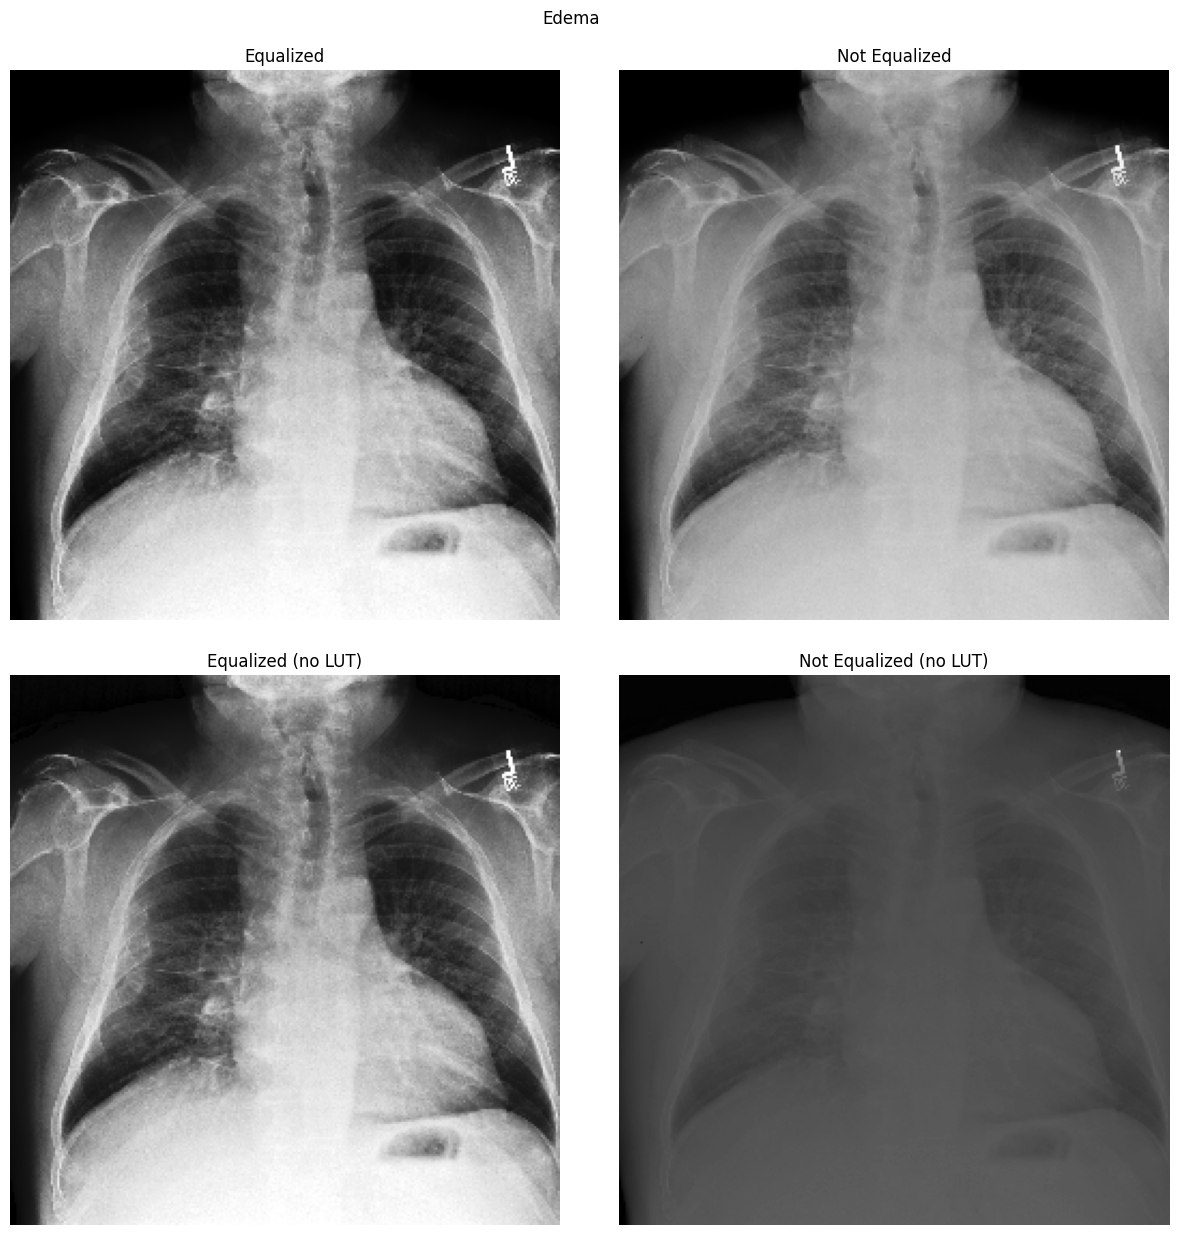

In [107]:
plot_CXR(df_test, 'Edema')

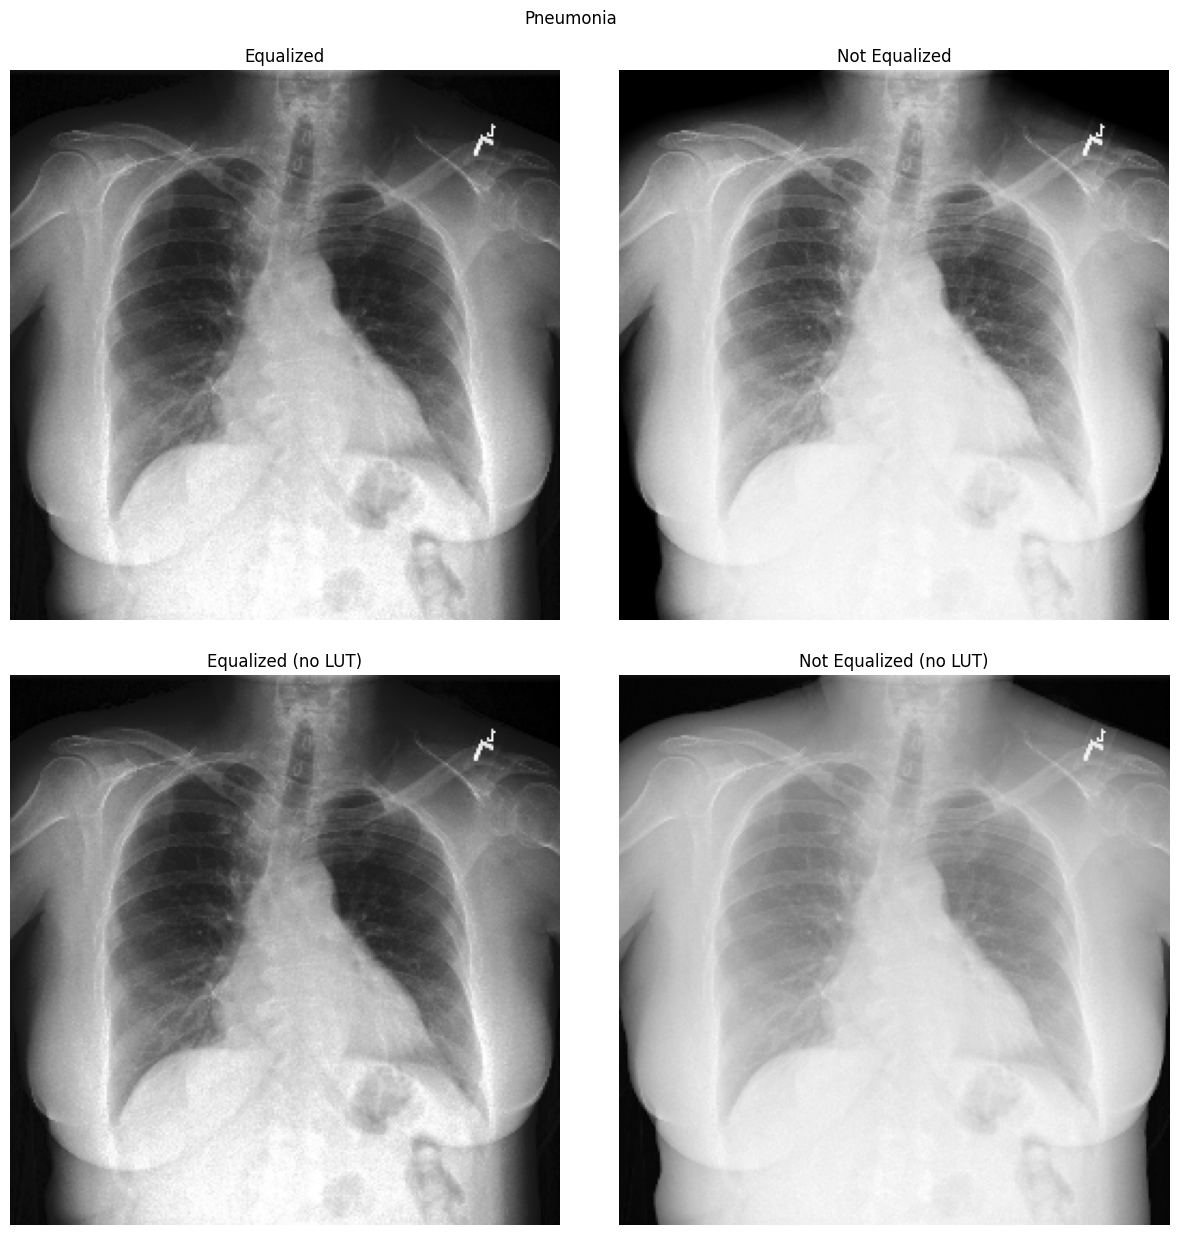

In [108]:
plot_CXR(df_test, 'Pneumonia')

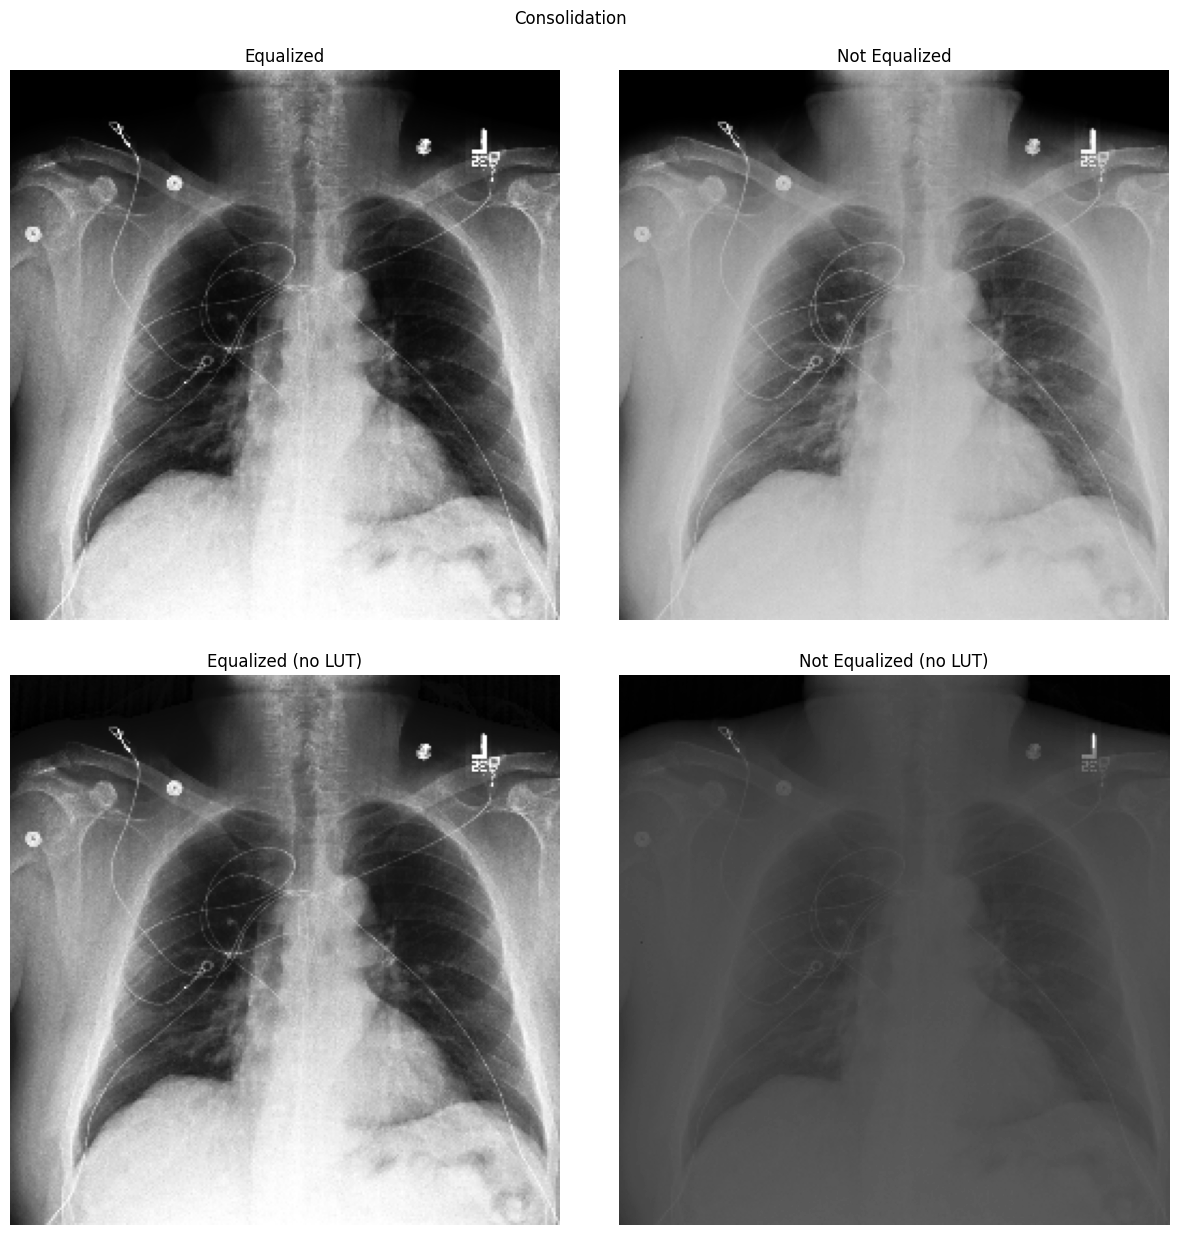

In [88]:
plot_CXR(df_test, 'Consolidation')

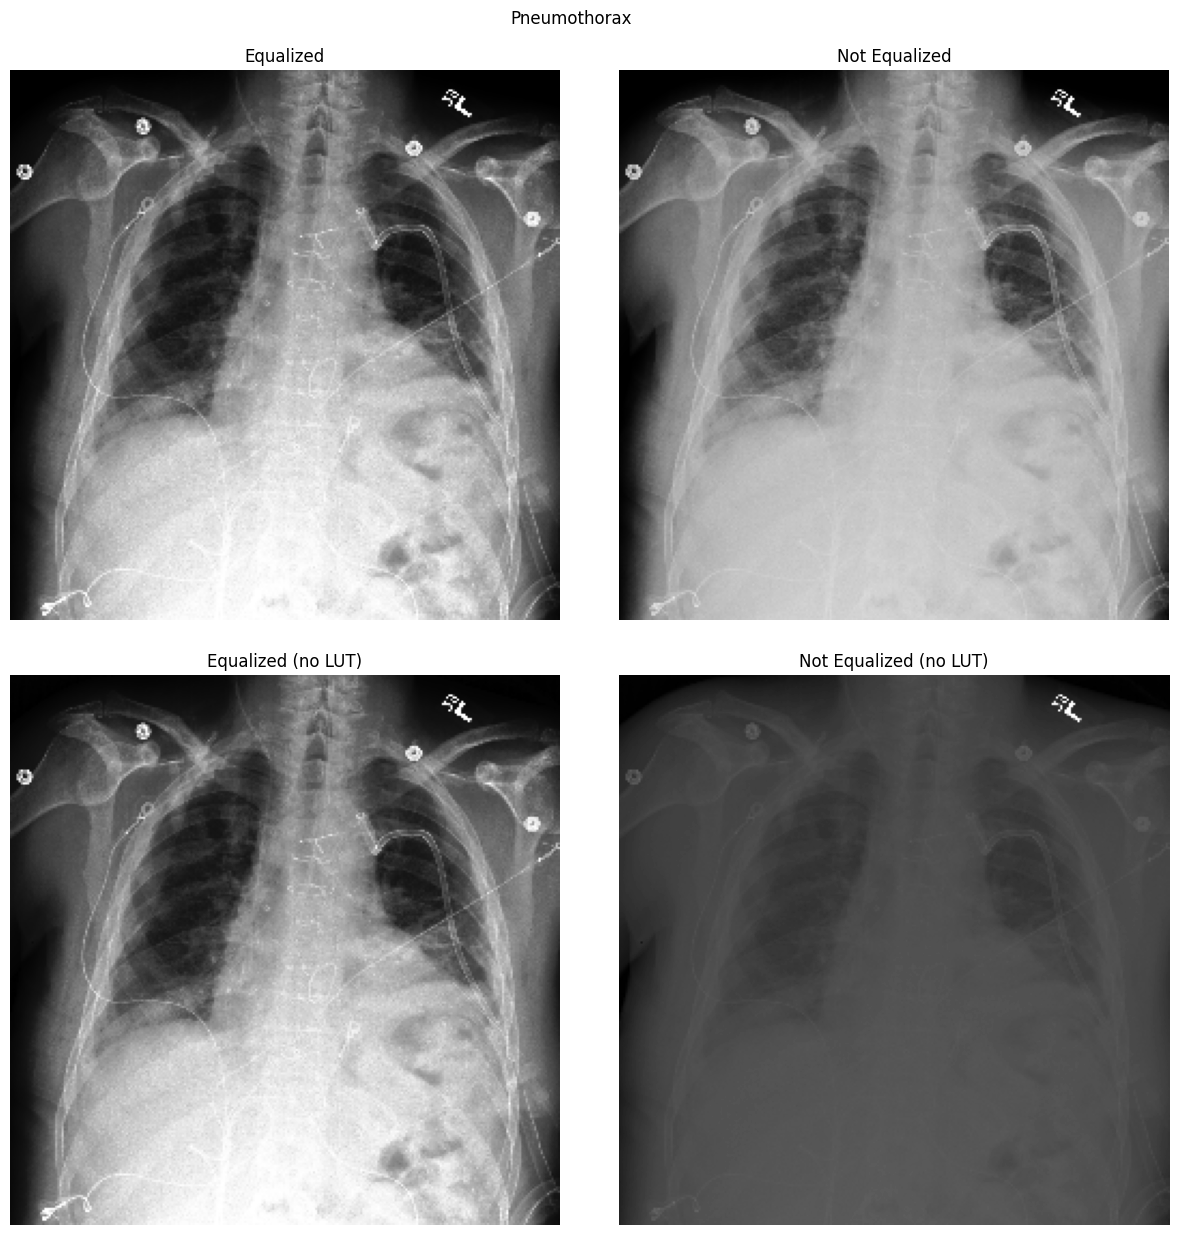

In [97]:
plot_CXR(df_test, 'Pneumothorax')

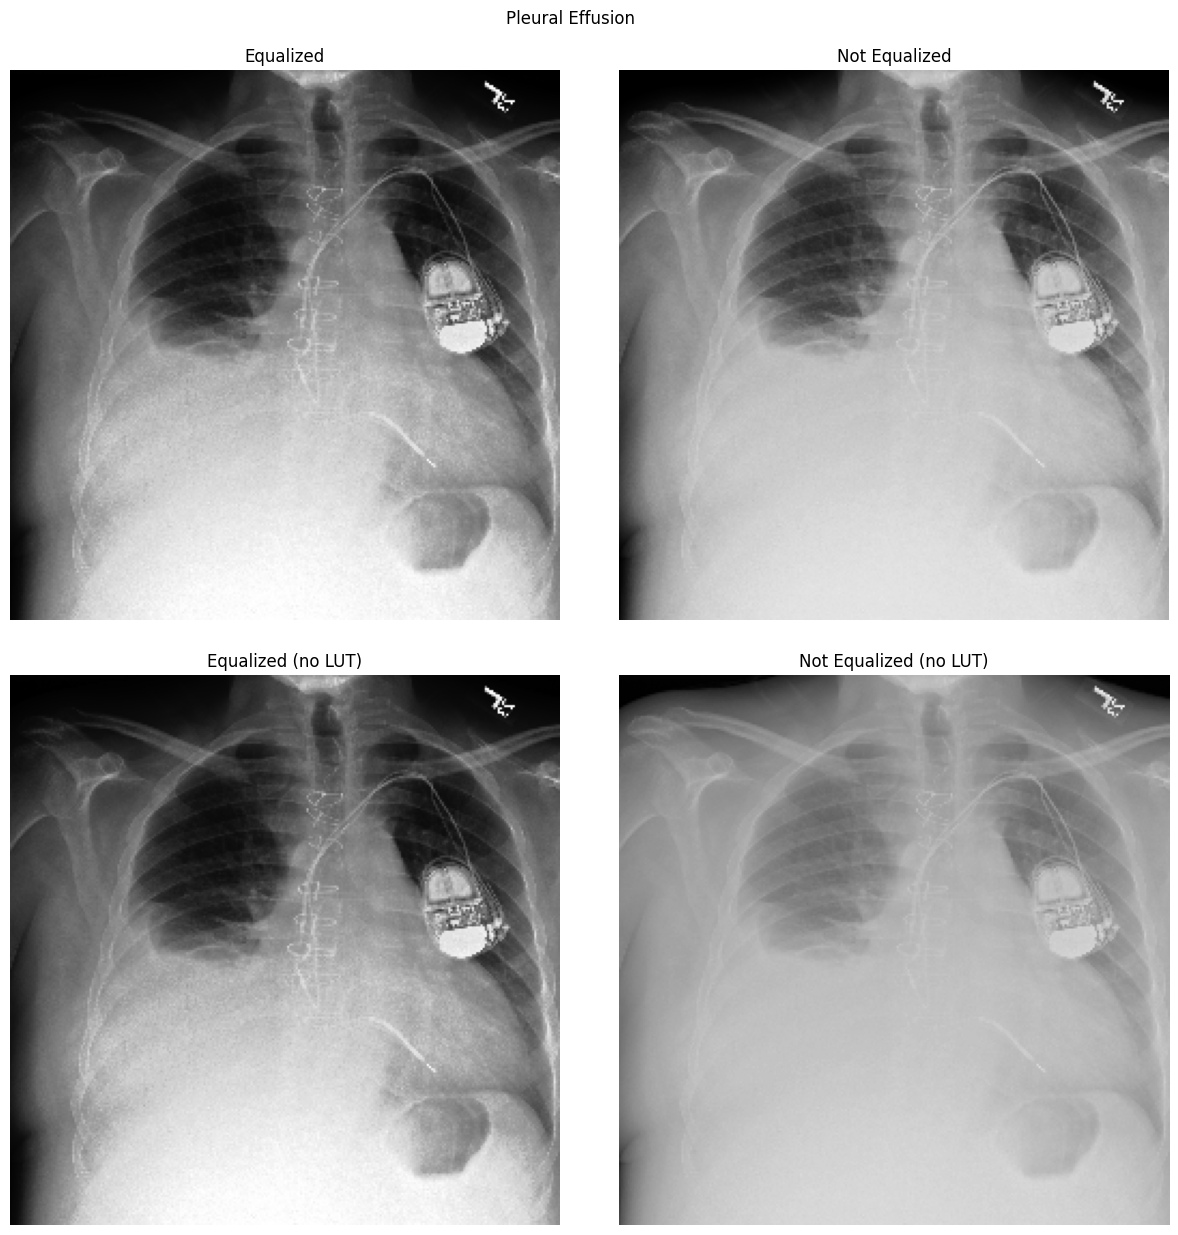

In [104]:
plot_CXR(df_test, 'Pleural Effusion')